In [28]:
import os
import random
import shutil
import zipfile
import cv2
import matplotlib.pyplot as plt

In [29]:
!kaggle datasets download -d anggadwisunarto/potholes-detection-yolov8 -p /kaggle/working/

Dataset URL: https://www.kaggle.com/datasets/anggadwisunarto/potholes-detection-yolov8
License(s): CC0-1.0
potholes-detection-yolov8.zip: Skipping, found more recently modified local copy (use --force to force download)


In [30]:
with zipfile.ZipFile("/kaggle/working/potholes-detection-yolov8.zip", "r") as z:
    z.extractall("/kaggle/working/pothole_data")

In [31]:
for root, dirs, files in os.walk("/kaggle/working/pothole_data"):
    level = root.replace("/kaggle/working/pothole_data", "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for f in files[:3]:
            print(f"{'  ' * (level+1)}{f}")

pothole_data/
  data.yaml
  sample_video.mp4
  valid/
    labels.cache
    labels/
    images/
  test/
    labels.cache
    labels/
    images/
  train/
    labels.cache
    labels/
    images/


In [32]:
val_img_dir = "/kaggle/working/pothole_data/valid/images"
val_label_dir = "/kaggle/working/pothole_data/valid/labels"

test_img_dir = "/kaggle/working/pothole_data/test/images"
test_label_dir = "/kaggle/working/pothole_data/test/labels"

In [33]:
os.makedirs(test_img_dir, exist_ok=True)
os.makedirs(test_label_dir, exist_ok=True)

In [34]:
val_imgs = os.listdir(val_img_dir)

In [35]:
random.shuffle(val_imgs)

In [36]:
split_idx = len(val_imgs) // 2
test_imgs = val_imgs[:split_idx]

In [37]:
for img_name in test_imgs:

    src_img = os.path.join(val_img_dir, img_name)
    dst_img = os.path.join(test_img_dir, img_name)

    shutil.move(src_img, dst_img)

    label_name = os.path.splitext(img_name)[0] + ".txt"

    src_label = os.path.join(val_label_dir, label_name)
    dst_label = os.path.join(test_label_dir, label_name)

    if os.path.exists(src_label):
        shutil.move(src_label, dst_label)

print("Dataset split completed")

Dataset split completed


In [38]:
data_yaml = """
path: /kaggle/working/pothole_data

train: train/images
val: valid/images
test: test/images

nc: 1
names: ['pothole']
"""

with open("/kaggle/working/pothole_data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml ready")

data.yaml ready


In [39]:
train_imgs = os.listdir("/kaggle/working/pothole_data/train/images")
val_imgs   = os.listdir("/kaggle/working/pothole_data/valid/images")
test_imgs  = os.listdir("/kaggle/working/pothole_data/test/images")

print(f"Train: {len(train_imgs)}")
print(f"Val:   {len(val_imgs)}")
print(f"Test:  {len(test_imgs)}")

Train: 1581
Val:   198
Test:  296


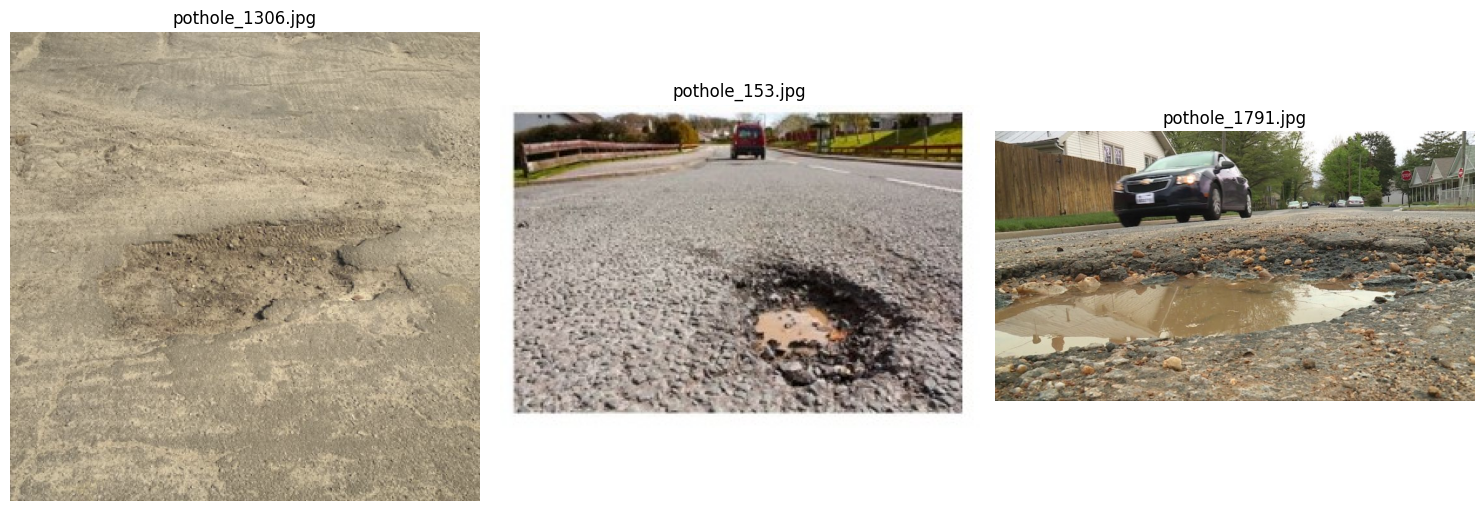

In [40]:
train_dir = "/kaggle/working/pothole_data/train/images"
train_imgs = os.listdir(train_dir)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):

    img_path = os.path.join(train_dir, train_imgs[i])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(train_imgs[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
!pip install ultralytics -q

In [42]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [43]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/kaggle/working/pothole_data.yaml",
    epochs=100,
    imgsz=640,
    batch=32,
    device=0,
    name="yolo_potholes",
    patience=20,
    cos_lr=True,
    augment=True,
    pretrained=True,
    verbose=True,
)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/pothole_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_potholes-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783be5196d50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [44]:
metrics = model.val(data="/kaggle/working/pothole_data.yaml", split="test")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1845.8±1182.9 MB/s, size: 239.8 KB)
val: Scanning /kaggle/working/pothole_data/test/labels... 295 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 296/296 370.9it/s 0.8s0.0s
val: /kaggle/working/pothole_data/test/images/pothole_1870.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'jpeg2000', 'avif', 'bmp', 'heif', 'jpeg', 'dng', 'mpo', 'jpg', 'jp2', 'tiff', 'png', 'webp', 'heic', 'tif'}
videos: {'gif', 'avi', 'mpeg', 'mov', 'm4v', 'mp4', 'wmv', 'asf', 'ts', 'mkv', 'mpg', 'webm'}
val: /kaggle/working/pothole_data/test/images/pothole_975.jpg: corrupt JPEG restored and saved
val: New cache created: /kaggle/working/pothole_data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95

In [45]:
print(metrics)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783be5fd32f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [46]:
model.val(data="/kaggle/working/pothole_data.yaml", split="test", plots=True)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1398.9±555.3 MB/s, size: 316.4 KB)
val: Scanning /kaggle/working/pothole_data/test/labels.cache... 295 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 296/296 137.9Mit/s 0.0s
val: /kaggle/working/pothole_data/test/images/pothole_1870.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'jpeg2000', 'avif', 'bmp', 'heif', 'jpeg', 'dng', 'mpo', 'jpg', 'jp2', 'tiff', 'png', 'webp', 'heic', 'tif'}
videos: {'gif', 'avi', 'mpeg', 'mov', 'm4v', 'mp4', 'wmv', 'asf', 'ts', 'mkv', 'mpg', 'webm'}
val: /kaggle/working/pothole_data/test/images/pothole_975.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.5it/s 7.6s0.4s
                   all        295       1085      0.815      0.735      0.799      0.534
Speed: 1.1ms prepr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783bc6203e60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [47]:
results = model.predict(
    source="/kaggle/working/pothole_data/test/images",
    conf=0.25,
    save=True
)


image 1/296 /kaggle/working/pothole_data/test/images/pothole_1001.jpg: 416x640 1 pothole, 43.1ms
image 2/296 /kaggle/working/pothole_data/test/images/pothole_1010.jpg: 640x640 3 potholes, 38.6ms
image 3/296 /kaggle/working/pothole_data/test/images/pothole_1025.jpg: 640x640 2 potholes, 36.9ms
image 4/296 /kaggle/working/pothole_data/test/images/pothole_1037.jpg: 384x640 6 potholes, 42.0ms
image 5/296 /kaggle/working/pothole_data/test/images/pothole_1044.jpg: 544x640 1 pothole, 41.9ms
image 6/296 /kaggle/working/pothole_data/test/images/pothole_1053.jpg: 448x640 1 pothole, 42.3ms
image 7/296 /kaggle/working/pothole_data/test/images/pothole_1056.jpg: 448x640 6 potholes, 19.8ms
image 8/296 /kaggle/working/pothole_data/test/images/pothole_1057.jpg: 640x640 2 potholes, 28.2ms
image 9/296 /kaggle/working/pothole_data/test/images/pothole_1078.jpg: 416x640 1 pothole, 20.6ms
image 10/296 /kaggle/working/pothole_data/test/images/pothole_1082.jpg: 448x640 1 pothole, 17.0ms
image 11/296 /kaggle/wo

In [48]:
import pandas as pd
df = pd.read_csv("runs/detect/yolo_potholes/results.csv")

print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


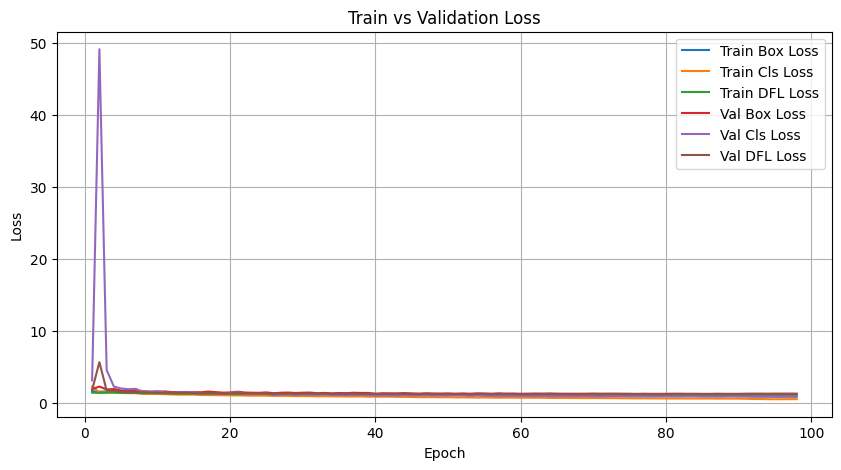

In [49]:
plt.figure(figsize=(10,5))

plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")

plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss")
plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

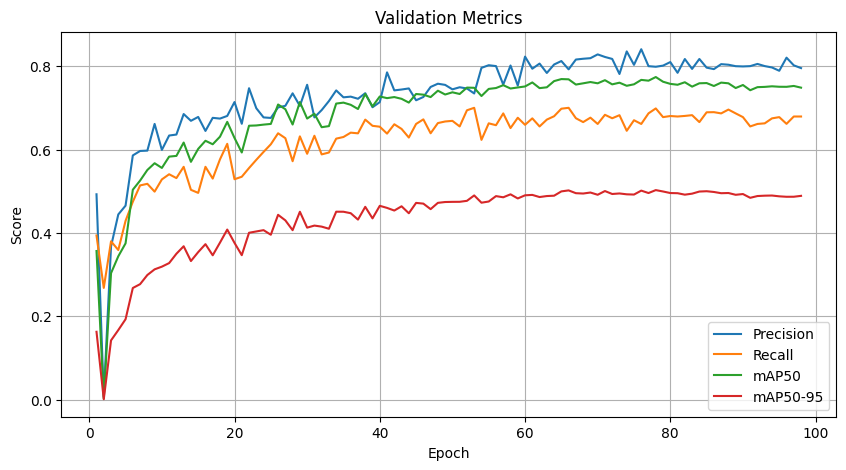

In [50]:
plt.figure(figsize=(10,5))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()
plt.grid()
plt.show()

In [51]:
test_metrics = model.val(
    data="/kaggle/working/pothole_data.yaml",
    split="test"
)

print(test_metrics)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1758.3±881.5 MB/s, size: 312.9 KB)
val: Scanning /kaggle/working/pothole_data/test/labels.cache... 295 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 296/296 137.9Mit/s 0.0s
val: /kaggle/working/pothole_data/test/images/pothole_1870.jpg: ignoring corrupt image/label: invalid image format GIF. Supported formats are:
images: {'jpeg2000', 'avif', 'bmp', 'heif', 'jpeg', 'dng', 'mpo', 'jpg', 'jp2', 'tiff', 'png', 'webp', 'heic', 'tif'}
videos: {'gif', 'avi', 'mpeg', 'mov', 'm4v', 'mp4', 'wmv', 'asf', 'ts', 'mkv', 'mpg', 'webm'}
val: /kaggle/working/pothole_data/test/images/pothole_975.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.4it/s 7.8s0.4s
                   all        295       1085      0.815      0.735      0.799      0.534
Speed: 1.2ms prepr

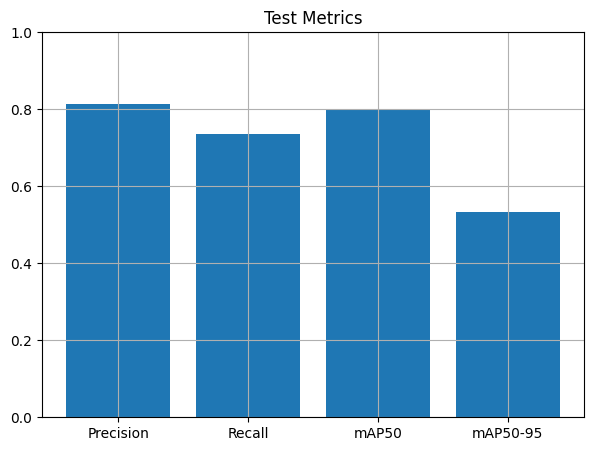

[0.814865661763822, 0.7345622119815668, 0.7985788611848164, 0.5336149706340689]


In [3]:
names = ["Precision", "Recall", "mAP50", "mAP50-95"]
values = [
    test_metrics.box.mp,
    test_metrics.box.mr,
    test_metrics.box.map50,
    test_metrics.box.map
]


plt.figure(figsize=(7,5))
plt.bar(names, values)
plt.title("Test Metrics")
plt.ylim(0, 1)
plt.grid()
plt.show()
print(values)